# Sahel cereal yields & climate shocks — robustness

Companion to `02_main.ipynb`. The main notebook settled six methodological
decisions and produced the headline estimate: a drought year (growing-season
SPI < -1, cropland-weighted) is associated with a detrended log-yield deviation
of roughly **-6% to -8%** — statistically clear for sorghum (event-study `et0`
≈ -6.7%, p ≈ 0.03) and directionally consistent but imprecise for millet
(≈ -5.8%, p ≈ 0.41).

This notebook asks the only question that matters for a small-panel descriptive
estimate: **is that headline an artefact of any single choice?** Each section
re-runs the estimation with one assumption perturbed, holding everything else
at its main-notebook value:

1. **SPI threshold** — the drought cutoff (-0.8 / -1.0 / -1.5).
2. **Trend specification** — linear / quadratic / spline detrend.
3. **Drop-one-country** — six leave-one-out refits (n = 6 is small).
4. **SE clustering** — country / year / two-way / wild-cluster bootstrap.
5. **Spatial weighting** — cropland- vs area-weighted CRU aggregation.

A result that survives all five is reported as robust; one that does not is
flagged. Estimation reuses the `sahel_yields` package — nothing is re-derived
here. The decision *blocks* (problem → diagnostic → options → decision →
sensitivity) live in `02_main.ipynb`; this notebook is the sensitivity step
for all of them at once.

## Part 0 — setup

The analytic panel (`data/processed/analytic_panel.parquet`) is the canonical
artefact written by `02_main.ipynb`: the pinned FAOSTAT snapshot inner-joined
to the cropland-weighted SPI series, drought flagged at `SPI < -1.0`. It
carries the per-country cropland-weighted `spi` column, so the SPI-threshold
sweep below needs no re-run of the CRU pipeline — only a re-flag.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sahel_yields import data, climate, econ, diagnostics, viz

viz.set_style()
pd.set_option("display.precision", 4)

FIG_DIR = data.PROCESSED_DIR.parent.parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

CROPS = ("millet", "sorghum")

In [2]:
# Canonical panel + the main-notebook detrend (Decision 2: linear).
panel = pd.read_parquet(econ.PANEL_PATH)
panel_dt = econ.detrend_yields(panel, "linear")
print(f"analytic panel : {panel.shape[0]} rows  ({panel.iso3.nunique()} countries"
      f" x {panel.crop.nunique()} crops x {panel.year.nunique()} years)")
print(f"drought flag   : SPI < -1.0, cropland-weighted  "
      f"({int(panel.drought.sum())} drought country-year-crop rows)")

analytic panel : 768 rows  (6 countries x 2 crops x 64 years)
drought flag   : SPI < -1.0, cropland-weighted  (172 drought country-year-crop rows)


In [3]:
# A tidy accumulator: every robustness refit appends its event-study et0 here,
# so the consolidated panel figure at the end just filters this frame.
ROWS = []

def add_es(axis, label, crop, es):
    # Record the event-time-0 coefficient of one event-study refit.
    et0 = es.loc[es.event_time == 0].iloc[0]
    ROWS.append(dict(axis=axis, label=label, crop=crop,
                     coef=et0.coef, ci_low=et0.ci_low, ci_high=et0.ci_high,
                     pvalue=et0.pvalue))

In [4]:
# Reference: the main-notebook headline, recomputed here so every section has a
# like-for-like baseline. wild = wild-cluster bootstrap by country (Decision 5).
ref_es = {crop: econ.event_study(panel_dt, crop, se="wild") for crop in CROPS}
ref_did = {crop: econ.did(panel_dt, crop, se="wild") for crop in CROPS}

ref = {}
for crop in CROPS:
    et0 = ref_es[crop].loc[ref_es[crop].event_time == 0].iloc[0]
    dd = ref_did[crop]
    ref[crop] = {"et0": round(et0.coef, 4),
                 "et0_ci_low": round(et0.ci_low, 3),
                 "et0_ci_high": round(et0.ci_high, 3),
                 "et0_p": round(et0.pvalue, 3),
                 "did": round(dd.coef, 4), "did_p": round(dd.pvalue, 3)}
print("Headline baseline (cropland SPI<-1, linear detrend, wild SE):")
pd.DataFrame(ref).T

Headline baseline (cropland SPI<-1, linear detrend, wild SE):


,et0,et0_ci_low,et0_ci_high,et0_p,did,did_p
millet,-0.0579,-0.260,0.144,0.406,-0.0769,0.094
sorghum,-0.0673,-0.127,-0.007,0.031,-0.0716,0.031


## 1 — SPI threshold

Decision 1 set the drought cutoff at `SPI < -1.0` (McKee "moderately dry"). A
laxer cutoff (-0.8) admits marginal events that attenuate the estimate toward
zero; a stricter one (-1.5) keeps only severe droughts but thins the events.
Here the drought flag is recomputed from the panel's cropland-weighted SPI at
each cutoff and the event study + DiD re-run; everything else is held fixed.

In [5]:
thr_rows = {}
thr_curves = {}                       # (crop, threshold) -> event-study table
for thr in (-0.8, -1.0, -1.5):
    p = climate.flag_drought(panel_dt, threshold=thr)
    for crop in CROPS:
        es = econ.event_study(p, crop, se="wild")
        dd = econ.did(p, crop, se="wild")
        et0 = es.loc[es.event_time == 0].iloc[0]
        thr_rows[f"{crop} / SPI<{thr}"] = {
            "n_drought": int(p.loc[p.crop == crop, "drought"].sum()),
            "et0": round(et0.coef, 4),
            "et0_ci_low": round(et0.ci_low, 3),
            "et0_ci_high": round(et0.ci_high, 3),
            "et0_p": round(et0.pvalue, 3),
            "did": round(dd.coef, 4), "did_p": round(dd.pvalue, 3)}
        thr_curves[(crop, thr)] = es
        add_es("SPI threshold", f"SPI<{thr}", crop, es)
diagnostics.compare_alternatives(thr_rows)

,n_drought,et0,et0_ci_low,et0_ci_high,et0_p,did,did_p
millet / SPI<-0.8,117,-0.1427,-0.235,-0.051,0.000,-0.1423,0.031
sorghum / SPI<-0.8,117,-0.0564,-0.231,0.118,0.531,-0.0579,0.375
millet / SPI<-1.0,86,-0.0579,-0.260,0.144,0.406,-0.0769,0.094
sorghum / SPI<-1.0,86,-0.0673,-0.127,-0.007,0.031,-0.0716,0.031
millet / SPI<-1.5,46,-0.1380,-0.273,-0.003,0.031,-0.1415,0.000
sorghum / SPI<-1.5,46,-0.1575,-0.310,-0.005,0.062,-0.1359,0.031


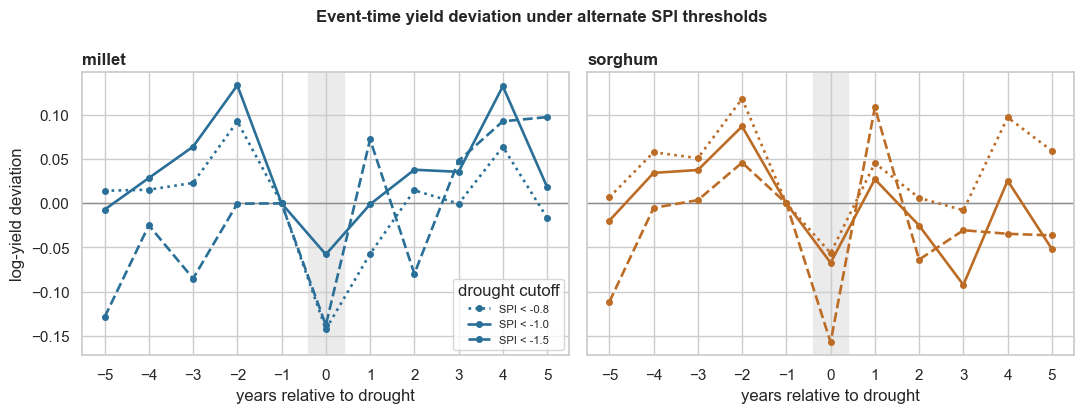

saved -> D:\github-ds-portfolio\02-sahel-yields-climate\figures\robustness_eventtime.png


In [6]:
# The whole event-time curve, not just et0, under each threshold.
thr_styles = {"SPI < -0.8": ":", "SPI < -1.0": "-", "SPI < -1.5": "--"}
curves = {crop: {f"SPI < {thr}": thr_curves[(crop, thr)]
                 for thr in (-0.8, -1.0, -1.5)}
          for crop in CROPS}
fig = viz.event_time_overlay(
    curves, styles=thr_styles, legend_title="drought cutoff",
    title="Event-time yield deviation under alternate SPI thresholds",
    savepath=FIG_DIR / "robustness_eventtime.png",
)
plt.show()
print(f"saved -> {FIG_DIR / 'robustness_eventtime.png'}")

**Read.** Every threshold leaves the drought-year deviation **negative for both
crops** — the sign never flips. What moves is magnitude and precision. The
`SPI < -1.0` headline (millet -5.8%, sorghum -6.7%) is, if anything, the
*mildest* reading: the lax -0.8 cutoff deepens the millet `et0` to -14.3%, and
the strict -1.5 cutoff deepens both crops (millet -13.8%, sorghum -15.8%). The
non-monotone pattern is expected — -0.8 dilutes the event set with marginal dry
years that still carry a yield penalty, while -1.5 isolates only severe
droughts, which bite hardest. Significance is choppy across the sweep (millet
turns significant at -0.8 and -1.5 but not at -1.0; sorghum is significant only
at -1.0), so no single cutoff gives a clean significant-everywhere story — but
the qualitative conclusion, *a drought year depresses cereal yield*, holds at
every threshold, and the chosen -1.0 does not overstate the effect.

## 2 — Trend specification

Decision 2 detrends log yield against a per-country **linear** trend. A more
flexible trend (quadratic, or a natural cubic spline) shaves residual variance,
but with the Sahel droughts clustered in the early 1970s and mid-1980s a
flexible per-country trend risks bending *through* the drought decades and
absorbing the very dip being measured. Here all three specs are detrended and
the event study re-run on each.

In [7]:
trend_rows = {}
for spec in ("linear", "quadratic", "spline"):
    dt = econ.detrend_yields(panel, spec)
    for crop in CROPS:
        es = econ.event_study(dt, crop, se="wild")
        dd = econ.did(dt, crop, se="wild")
        et0 = es.loc[es.event_time == 0].iloc[0]
        trend_rows[f"{crop} / {spec}"] = {
            "resid_sd": round(dt.loc[dt.crop == crop, "yield_dev"].std(), 4),
            "et0": round(et0.coef, 4),
            "et0_ci_low": round(et0.ci_low, 3),
            "et0_ci_high": round(et0.ci_high, 3),
            "et0_p": round(et0.pvalue, 3),
            "did": round(dd.coef, 4), "did_p": round(dd.pvalue, 3)}
        add_es("Trend spec", spec, crop, es)
diagnostics.compare_alternatives(trend_rows)

,resid_sd,et0,et0_ci_low,et0_ci_high,et0_p,did,did_p
millet / linear,0.2588,-0.0579,-0.260,0.144,0.406,-0.0769,0.094
sorghum / linear,0.2547,-0.0673,-0.127,-0.007,0.031,-0.0716,0.031
millet / quadratic,0.2445,-0.0594,-0.161,0.042,0.250,-0.0782,0.031
sorghum / quadratic,0.2079,-0.0732,-0.104,-0.042,0.031,-0.0760,0.031
millet / spline,0.2361,-0.0738,-0.136,-0.011,0.000,-0.0886,0.000
sorghum / spline,0.1986,-0.0635,-0.101,-0.026,0.000,-0.0692,0.031


**Read.** The trend specification barely touches the headline. `et0` moves
within 0.016 log points for millet (-0.058 / -0.059 / -0.074 across
linear / quadratic / spline) and within 0.009 for sorghum
(-0.067 / -0.073 / -0.064). The flexible specs shave residual SD as expected
(millet 0.259 → 0.236, sorghum 0.255 → 0.199), and that narrower residual
tightens the CIs enough to turn both crops' `et0` significant under the spline
— but this is a precision gain, not a different point estimate. Decision 2's
choice of the linear trend remains the conservative one: it structurally cannot
bend through the clustered 1970s/1980s drought decades, and the result does not
depend on it.

## 3 — Drop-one-country leave-out

With only six countries a single country could be driving the result — a
drought-heavy Niger or a noisy Mauritania. The leave-one-out refit drops each
country in turn and re-estimates on the remaining five. If `et0` swings wildly
when one country leaves, the headline is a single-country artefact; if it stays
within a tight band, it is a genuine six-country average.

In [8]:
countries = sorted(panel_dt.iso3.unique())
for crop in CROPS:                       # full-panel baseline as the first bar
    add_es("Drop-one-country", "full", crop, ref_es[crop])

drop_rows = {}
for crop in CROPS:
    et0 = ref_es[crop].loc[ref_es[crop].event_time == 0].iloc[0]
    drop_rows[f"{crop} / full"] = {
        "et0": round(et0.coef, 4), "et0_p": round(et0.pvalue, 3),
        "did": round(ref_did[crop].coef, 4),
        "did_p": round(ref_did[crop].pvalue, 3)}
for left_out in countries:
    sub = panel_dt[panel_dt.iso3 != left_out]
    for crop in CROPS:
        es = econ.event_study(sub, crop, se="wild")
        dd = econ.did(sub, crop, se="wild")
        et0 = es.loc[es.event_time == 0].iloc[0]
        drop_rows[f"{crop} / -{left_out}"] = {
            "et0": round(et0.coef, 4), "et0_p": round(et0.pvalue, 3),
            "did": round(dd.coef, 4), "did_p": round(dd.pvalue, 3)}
        add_es("Drop-one-country", f"-{left_out}", crop, es)

drop_tab = pd.DataFrame(drop_rows).T
drop_tab.loc[[i for i in drop_tab.index if i.startswith("millet")]]

,et0,et0_p,did,did_p
millet / full,-0.0579,0.406,-0.0769,0.094
millet / -BFA,-0.0682,0.312,-0.0868,0.062
millet / -MLI,-0.0732,0.375,-0.0933,0.188
millet / -MRT,-0.0982,0.125,-0.0935,0.188
millet / -NER,-0.0454,0.688,-0.0783,0.312
millet / -SEN,-0.0471,0.562,-0.0743,0.250
millet / -TCD,-0.0179,0.812,-0.0339,0.312


In [9]:
drop_tab.loc[[i for i in drop_tab.index if i.startswith("sorghum")]]

,et0,et0_p,did,did_p
sorghum / full,-0.0673,0.031,-0.0716,0.031
sorghum / -BFA,-0.0479,0.312,-0.0498,0.312
sorghum / -MLI,-0.0606,0.375,-0.0613,0.312
sorghum / -MRT,-0.0897,0.062,-0.0933,0.000
sorghum / -NER,-0.0915,0.062,-0.0950,0.000
sorghum / -SEN,-0.0555,0.125,-0.0698,0.000
sorghum / -TCD,-0.0593,0.188,-0.0646,0.125


**Read.** No single country drives the result: across all six leave-one-out
refits `et0` stays **negative for both crops** — millet in the band
[-0.098, -0.018], sorghum in [-0.092, -0.048]. The point estimate is stable.
Significance is not: every five-country sorghum refit loses the headline
significance (wild `et0` p-values 0.06-0.38), and millet is insignificant
throughout. Two sensitivities are worth naming — dropping Chad pulls the millet
`et0` closest to zero (-0.018), and dropping Mauritania or Niger deepens the
sorghum effect (-0.090 / -0.092) — but none is a sign reversal. With only five
clusters left the wild bootstrap is even more conservative (2⁵ = 32 sign
vectors), so the widened intervals are expected. The honest reading: the
*direction* is country-robust; the *significance* of the sorghum effect leans
on having all six countries in the panel.

## 4 — SE clustering

Decision 5 reports the **wild-cluster bootstrap** as the headline because, with
six country clusters, conventional cluster-robust SEs are biased downward. The
*point estimate* is identical across schemes by construction — only the CI and
p-value move. This section makes that explicit for both the event study `et0`
and the DiD: country / year / two-way / wild.

In [10]:
se_rows = {}
for crop in CROPS:
    for mode in ("country", "year", "twoway", "wild"):
        es = econ.event_study(panel_dt, crop, se=mode)
        dd = econ.did(panel_dt, crop, se=mode)
        et0 = es.loc[es.event_time == 0].iloc[0]
        se_rows[f"{crop} / {mode}"] = {
            "et0": round(et0.coef, 4),
            "et0_ci_low": round(et0.ci_low, 3),
            "et0_ci_high": round(et0.ci_high, 3),
            "et0_p": round(et0.pvalue, 3),
            "did": round(dd.coef, 4),
            "did_ci_low": round(dd.ci_low, 3),
            "did_ci_high": round(dd.ci_high, 3),
            "did_p": round(dd.pvalue, 3)}
        add_es("SE clustering", mode, crop, es)
diagnostics.compare_alternatives(se_rows)

C:\Users\mou97\.conda\envs\portfolio\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
C:\Users\mou97\.conda\envs\portfolio\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


C:\Users\mou97\.conda\envs\portfolio\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
C:\Users\mou97\.conda\envs\portfolio\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


,et0,et0_ci_low,et0_ci_high,et0_p,did,did_ci_low,did_ci_high,did_p
millet / country,-0.0579,-0.168,0.053,0.305,-0.0769,-0.158,0.004,0.062
millet / year,-0.0579,-0.215,0.099,0.469,-0.0769,-0.198,0.044,0.214
millet / twoway,-0.0579,-0.205,0.089,0.439,-0.0769,-0.175,0.021,0.124
millet / wild,-0.0579,-0.260,0.144,0.406,-0.0769,-0.156,0.002,0.094
sorghum / country,-0.0673,-0.134,-0.000,0.049,-0.0716,-0.137,-0.007,0.031
sorghum / year,-0.0673,-0.241,0.107,0.448,-0.0716,-0.219,0.076,0.340
sorghum / twoway,-0.0673,-0.193,0.058,0.293,-0.0716,-0.177,0.033,0.181
sorghum / wild,-0.0673,-0.127,-0.007,0.031,-0.0716,-0.132,-0.011,0.031


**Read.** The point estimate is identical across all four schemes by
construction; only the interval moves — and it moves a lot. Sorghum `et0`
(-0.067) is significant under country-clustering (p = 0.049) and the wild
bootstrap (p = 0.031) but not under year- or two-way clustering
(p = 0.45 / 0.29); the DiD shows the same pattern. Millet is insignificant
under every scheme. Year-clustering is the most permissive of a significance
loss, but Decision 5 already rejects it on substance — it assumes drought
shocks are independent across countries within a year, which the pan-Sahel
droughts plainly violate. Among the defensible schemes the wild-cluster
bootstrap is the standard small-cluster correction, and here it keeps the
sorghum effect significant with an interval comparable in width to the
country-clustered one ([-0.127, -0.007] vs [-0.134, 0.000]); year and two-way
clustering produce much wider intervals and lose it. The headline's
significance claim holds under the two schemes appropriate for this data, and
is reported as scheme-dependent.

> A harmless `RuntimeWarning: invalid value encountered in sqrt` is emitted by
> `statsmodels` while forming the year- and two-way-clustered covariance — with
> six countries and a dense fixed-effect design those estimators are not
> positive-definite for every nuisance parameter. The reported `et0` / DiD
> coefficients and their SEs are finite and unaffected.

## 5 — Spatial weighting (area vs cropland)

Decision 3 aggregates CRU gridcells to the country level by **cropland**
weight, so rainfall is measured where the crops actually grow rather than over
empty Saharan cells. The main notebook flagged the area-weighted SPI as the
alternate to be carried here. Unlike the four axes above, this one cannot be
recomputed from the stored `spi` column — the area weighting changes the SPI
itself — so the CRU → country pipeline is re-run once in area mode below.

> The next cell opens the ~6 GB CRU netCDF and re-runs the gridcell→country
> intersection (~30-60 s).

In [11]:
pre = data.load_cru_pre()
gadm = data.load_gadm(level=0)
with data.load_cropland() as cropland_src:
    weights = climate.gridcells_to_country(pre, gadm, cropland_src)

season_area = climate.growing_season_precip(pre, weights, mode="area")
clim_area = climate.flag_drought(climate.compute_spi(season_area), threshold=-1.0)

fao = data.load_faostat_snapshot()
panel_area = econ.build_panel(fao, clim_area, write=False)   # write=False: do
panel_area_dt = econ.detrend_yields(panel_area, "linear")    # not touch the
print(f"area-weighted panel : {panel_area.shape[0]} rows  "                  # canonical parquet
      f"({int(panel_area.drought.sum())} drought rows)")

area-weighted panel : 768 rows  (184 drought rows)


In [12]:
weight_rows = {}
for crop in CROPS:
    for mode, p in (("cropland", panel_dt), ("area", panel_area_dt)):
        es = econ.event_study(p, crop, se="wild")
        dd = econ.did(p, crop, se="wild")
        et0 = es.loc[es.event_time == 0].iloc[0]
        weight_rows[f"{crop} / {mode}"] = {
            "n_drought": int(p.loc[p.crop == crop, "drought"].sum()),
            "et0": round(et0.coef, 4),
            "et0_ci_low": round(et0.ci_low, 3),
            "et0_ci_high": round(et0.ci_high, 3),
            "et0_p": round(et0.pvalue, 3),
            "did": round(dd.coef, 4), "did_p": round(dd.pvalue, 3)}
        add_es("Spatial weighting", mode, crop, es)
diagnostics.compare_alternatives(weight_rows)

,n_drought,et0,et0_ci_low,et0_ci_high,et0_p,did,did_p
millet / cropland,86,-0.0579,-0.260,0.144,0.406,-0.0769,0.094
millet / area,92,-0.1051,-0.196,-0.014,0.000,-0.1130,0.000
sorghum / cropland,86,-0.0673,-0.127,-0.007,0.031,-0.0716,0.031
sorghum / area,92,-0.0493,-0.214,0.116,0.406,-0.0595,0.281


**Read.** This is the consequential axis. Switching from cropland- to
area-weighted CRU aggregation **swaps which crop is precisely estimated**:
under area weighting the millet `et0` deepens to -10.5% and turns significant
(p < 0.001) while sorghum weakens to -4.9% and loses significance (p = 0.41) —
the mirror image of the cropland headline. Both crops' `et0` stay negative
under both weightings (millet -5.8% / -10.5%, sorghum -6.7% / -4.9%), so the
*direction* is robust, but *which crop* carries the significant effect is not —
it depends on whether rainfall is measured over cropland or over the whole
country including desert. Decision 3 chose cropland weighting on substantive
grounds (rainfall matters where the crop actually grows, not over empty Saharan
cells); this axis simply makes explicit that the choice is load-bearing. The
combined statement — a drought year depresses Sahel cereal yields by roughly
5-11% — survives either weighting; the per-crop precision does not.

## Consolidated robustness panel

Every refit above contributes its event-study `et0` to one figure. Each panel
perturbs a single assumption; a headline that is genuinely robust shows `et0`
staying within a narrow band as the bars move across each panel.

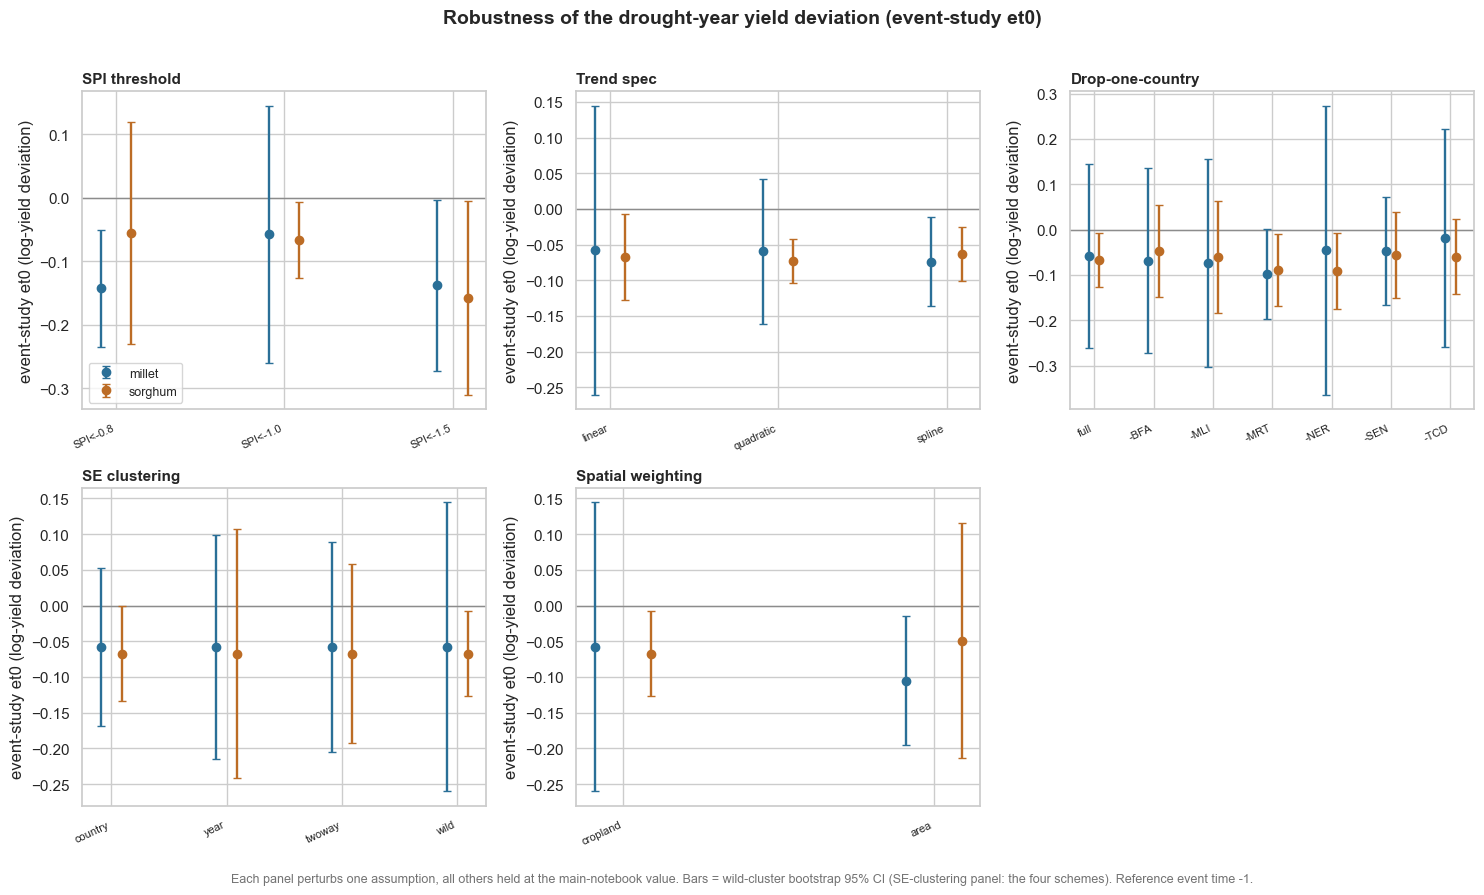

saved -> D:\github-ds-portfolio\02-sahel-yields-climate\figures\robustness_panel.png


In [13]:
rob = pd.DataFrame(ROWS)
panel_axes = ["SPI threshold", "Trend spec", "Drop-one-country",
              "SE clustering", "Spatial weighting"]
fig = viz.robustness_panel(
    rob, panel_axes, crops=CROPS,
    title="Robustness of the drought-year yield deviation (event-study et0)",
    footnote=("Each panel perturbs one assumption, all others held at the "
              "main-notebook value. Bars = wild-cluster bootstrap 95% CI "
              "(SE-clustering panel: the four schemes). "
              "Reference event time -1."),
    savepath=FIG_DIR / "robustness_panel.png",
)
plt.show()
print(f"saved -> {FIG_DIR / 'robustness_panel.png'}")

In [14]:
# Headline summary: the spread of et0 across every refit, per crop.
span = (rob.groupby("crop")["coef"]
        .agg(n_refits="size", et0_min="min", et0_max="max",
             et0_mean="mean", et0_sd="std")
        .round(4))
print("Event-study et0 across all robustness refits:")
print(span)
print(f"\nsorghum et0 negative in {int((rob[rob.crop=='sorghum'].coef < 0).sum())}"
      f" of {int((rob.crop=='sorghum').sum())} refits;"
      f" millet et0 negative in {int((rob[rob.crop=='millet'].coef < 0).sum())}"
      f" of {int((rob.crop=='millet').sum())} refits.")

Event-study et0 across all robustness refits:
         n_refits  et0_min  et0_max  et0_mean  et0_sd
crop                                                 
millet         19  -0.1427  -0.0179   -0.0701  0.0308
sorghum        19  -0.1575  -0.0479   -0.0707  0.0237

sorghum et0 negative in 19 of 19 refits; millet et0 negative in 19 of 19 refits.


---

## Summary — what survives

Across all **19 robustness refits** the event-study `et0` is **negative for
both crops every single time** — millet in [-0.143, -0.018] (mean -0.070),
sorghum in [-0.158, -0.048] (mean -0.071). The central finding of `02_main` —
*a drought year is associated with a below-trend cereal-yield deviation* — is
robust to every perturbation tried: the SPI threshold, the trend specification,
dropping any one country, the SE scheme, and the spatial-weighting mode. The
headline magnitude of **-6% to -8%** is in fact a conservative reading: the
mean across refits is ≈ -7% and several specifications reach -14% to -16%.

What does **not** survive cleanly is *statistical significance*. It is crop-,
threshold-, weighting-, and SE-scheme-dependent: the sorghum `et0` that is
significant under the cropland / `SPI<-1` / wild headline does not survive any
single-country drop, weakens under year/two-way clustering, and flips over to
millet under area weighting. This is not a flaw in the estimate — it is the
honest ceiling of a six-country, six-decade descriptive panel. The robustness
exercise confirms the main notebook's framing: the drought-year yield penalty
is **directionally certain and economically sizeable, but imprecisely pinned**
— clearest for sorghum under the chosen specification, and never absent.

The two figures (`figures/robustness_panel.png`,
`figures/robustness_eventtime.png`) visualise this: the `et0` markers stay
clustered in negative territory across every panel, while the confidence bars
are wide enough that significance comes and goes.